# Inspect and evaluate a saved WiFi model

Select **one** historical run. No CNN training, data discovery, or random re-splitting is performed.
The saved manifest determines recordings, labels, model architecture and exact segment order.

- For saved metrics and training curves only: run through **Training history**, then stop. This does not load signal data or use the GPU.
- For fresh evaluation: continue through restoration, export, scoring, calibration and prediction. A new `conformal-*` directory preserves older results.
- Embedding projections are optional. Background diagnostics use the saved heads without training any model.
- Restart the kernel before selecting a different run, especially after GPU training in another session.

Memory: NPY signals are memory-mapped on CPU; only one small inference batch enters the device, with gradients disabled. Checkpoints stay on CPU. Embeddings and scores still occupy **system RAM**; projection sampling limits computation, but compressed NPZ exports must be decompressed in RAM. Reduce `inference.batch_size` in baseline.yaml (or evaluation YAML) to 2 or 1 if CUDA runs out of memory, or choose `device_name = "cpu"`. A small batch cannot free GPU memory held by another notebook/kernel.

In [1]:
from pathlib import Path
import json

project_root = None  # Set the project directory if launching elsewhere.
PROJECT_ROOT = Path(project_root or Path.cwd()).expanduser().resolve()
if (PROJECT_ROOT / "step02_models").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
PYTHON_ROOT = PROJECT_ROOT / "python"
NPY_ROOT = PYTHON_ROOT / "dataset"
available_runs = sorted(p.parent for p in (PYTHON_ROOT / "runs").glob("*/best.pt")
                        if (p.parent / "experiment.json").is_file())
for p in available_runs:
    print(p.name)

20260930T021625682982Z
20260930T171702459791Z
20260930T172419222882Z
20260930T185259940907Z
20260930T194002338844Z
20260930T202340892947Z
20260930T210540456937Z
20261001T192314897806Z


In [ ]:
run_path = "20261005T045346921595Z"  # REQUIRED: e.g. "20261001T192314897806Z", or an absolute run directory.
checkpoint_name = "best.pt"  # Another compatible checkpoint in the same run is also supported.
saved_evaluation = None  # None selects the latest completed conformal-*; or give its directory name.
evaluation_config_path = None  # Optional YAML override for inference/score/calibration/weighting/alpha_grid.
device_name = "auto"  # "auto", "cuda", or "cpu"
run_embedding_projections = True
log_to_wandb = False

## Open the selected run and inspect saved results

In [3]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
if run_path is None:
    raise ValueError("Set run_path to one of the run directories listed above, then rerun this cell.")
run_dir = Path(run_path).expanduser()
if not run_dir.is_absolute():
    run_dir = PYTHON_ROOT / (run_dir if run_dir.parts[0] == "runs" else Path("runs") / run_dir)
run_dir = run_dir.resolve()
checkpoint_path = run_dir / checkpoint_name
if not checkpoint_path.is_file():
    raise FileNotFoundError(checkpoint_path)
experiment = json.loads((run_dir / "experiment.json").read_text())
result = (json.loads((run_dir / "history.json").read_text())
          if (run_dir / "history.json").exists() else {"history": [], "best_epoch": None})
saved_dirs = sorted(p.parent for p in run_dir.glob("conformal-*/metrics.json")
                    if (p.parent / "config.json").exists())
if saved_evaluation is None:
    saved_dir = saved_dirs[-1] if saved_dirs else None
else:
    saved_dir = Path(saved_evaluation).expanduser()
    if not saved_dir.is_absolute():
        saved_dir = run_dir / saved_dir
    if saved_dir.resolve().parent != run_dir:
        raise ValueError("Choose a saved evaluation belonging to the selected run")
print("Run:", run_dir)
print("Checkpoint:", checkpoint_path.name)
print("Classes:", experiment["class_names"])
print("Saved split sizes:", {k: len(v) for k, v in experiment["splits"].items()})
print("Completed evaluations:", [p.name for p in saved_dirs])
if saved_dir is not None:
    print("Saved results (not a new evaluation):", saved_dir)
    saved_provenance = json.loads((saved_dir / "config.json").read_text())
    print("Saved result checkpoint:", saved_provenance.get("checkpoint"),
          "epoch:", saved_provenance.get("checkpoint_epoch"))
    print((saved_dir / "metrics.json").read_text())
else:
    print("No completed evaluation saved yet. Continue below to evaluate this checkpoint.")

Run: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261001T192314897806Z
Checkpoint: best.pt
Classes: ['doc', 'sit', 'squat', 'walk', 'wipe']
Saved split sizes: {'train': 2356, 'validation': 335, 'calibration': 672, 'test': 373, 'reference': 537}
Completed evaluations: []
No completed evaluation saved yet. Continue below to evaluate this checkpoint.


## Training history
Read-only: the existing training plot is not overwritten.

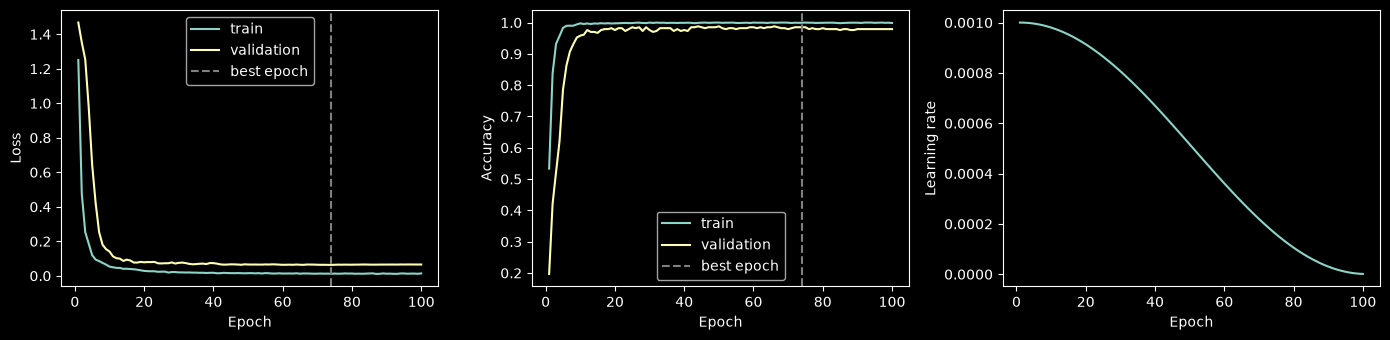

In [4]:
import matplotlib.pyplot as plt

history = result["history"]
epochs = [r["epoch"] for r in history]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, metric in zip(axes, ("loss", "accuracy")):
    for split in ("train", "validation"):
        ax.plot(epochs, [r[f"{split}_{metric}"] for r in history], label=split)
    if result.get("best_epoch") is not None:
        ax.axvline(result["best_epoch"], color="gray", linestyle="--", label="best epoch")
    ax.set(xlabel="Epoch", ylabel=metric.capitalize())
    ax.legend()
axes[2].plot(epochs, [r["learning_rate"] for r in history])
axes[2].set(xlabel="Epoch", ylabel="Learning rate")
fig.tight_layout()

plt.show()

## Restore evaluation settings
Historical CP settings take priority over a saved run YAML. If neither exists, current baseline settings are explicitly reported as defaults, not historical settings. Partial YAML overrides change only score, calibration, weighting and alpha_grid fields explicitly supplied. Older calibration configs without weighted_cp restore unweighted CP.

Fresh weighted evaluation always estimates weights from unlabeled test inputs. Obsolete weighting selectors in saved settings are discarded with a migration message. The saved train/validation/calibration/test membership is preserved; any extra historical split is ignored, not merged into training. Existing result directories remain unchanged.

The encoder/decoder architecture is restored exclusively from the saved run; no network training occurs here.


In [ ]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
import sys
import copy
import numpy as np
import torch
from collections import Counter
from dataclasses import asdict, fields
from torch.utils.data import Dataset, DataLoader
if str(PYTHON_ROOT) not in sys.path:
    sys.path.insert(0, str(PYTHON_ROOT))
from step00_config.loader import BASELINE
from step00_config.schema import InferenceConfig
import yaml
from step00_config.schema import KDEConfig, SVMConfig, HBGBConfig, SoftmaxConfig, CalibrationConfig, WeightingConfig
from step00_config.schema import ModelConfig, AdversarialConfig, EncoderBackgroundConfig, EncoderTaskConfig, DecoderConfig
from step01_preprocessing.standardize import standardize_time
from step02_models.build import build_model

if device_name not in ("auto", "cpu", "cuda"):
    raise ValueError("device_name must be auto, cpu or cuda")
device = torch.device(("cuda" if torch.cuda.is_available() else "cpu") if device_name == "auto" else device_name)
# Read only evaluation sections; training defaults must not reinterpret saved splits.
score_types = {"kde": KDEConfig, "svm": SVMConfig, "hbgb": HBGBConfig, "softmax": SoftmaxConfig}
def merge_evaluation_settings(base, patch):
    merged = copy.deepcopy(base)
    for key in ("score", "calibration", "alpha_grid", "weighting", "inference"):
        if key not in patch:
            continue
        value = copy.deepcopy(patch[key])
        if key == "alpha_grid":
            merged[key] = value
        else:
            if not isinstance(value, dict):
                raise ValueError(f"{key} must be a mapping")
            if key == "score" and value.get("kind", merged[key]["kind"]) != merged[key]["kind"]:
                merged[key] = asdict(score_types[value["kind"]]())
            merged.setdefault(key, {}).update(value)
    return merged

baseline = yaml.safe_load(BASELINE.read_text())
config = {k: copy.deepcopy(baseline[k]) for k in ("score", "calibration", "alpha_grid")}
settings_source = "CURRENT baseline defaults (not historical evaluation settings)"
historical_config = None
if (run_dir / "config.yaml").exists():
    historical_config = yaml.safe_load((run_dir / "config.yaml").read_text())
    settings_source = str(run_dir / "config.yaml")
if saved_dir is not None:
    historical_config = json.loads((saved_dir / "config.json").read_text())
    settings_source = str(saved_dir / "config.json")
if historical_config is not None:
    # Missing fields in older calibration configs use schema defaults, not today's YAML.
    historical_config = copy.deepcopy(historical_config)
    if "calibration" in historical_config:
        historical_config["calibration"] = asdict(CalibrationConfig(**historical_config["calibration"]))
    config = merge_evaluation_settings(config, historical_config)

# Historical split membership is preserved; obsolete weighting selectors are ignored.
config["weighting"] = copy.deepcopy((historical_config or {}).get("weighting", experiment.get("weighting", {})))
legacy_weighting = any(k in config["weighting"] for k in ("reference", "reference_domains"))
for obsolete in ("reference", "reference_domains"):
    config["weighting"].pop(obsolete, None)
if legacy_weighting:
    settings_source += "; migrated historical weighting to unlabeled target inputs"
# Inference memory budget uses current baseline, independent of the saved run.
config["inference"] = copy.deepcopy(baseline["inference"])
if evaluation_config_path is not None:
    override = yaml.safe_load(Path(evaluation_config_path).expanduser().read_text())
    if not isinstance(override, dict):
        raise ValueError("Evaluation YAML must contain a mapping")
    config = merge_evaluation_settings(config, override)
    settings_source += f"; explicit evaluation overrides: {evaluation_config_path}"
config["weighting"] = asdict(WeightingConfig(**config["weighting"]))
inference_batch_size = InferenceConfig(**config["inference"]).batch_size
split_config = experiment["split"]
split_seed, training_seed = experiment["split_seed"], experiment["training_seed"]
class_names = experiment["class_names"]
time_shape, stft_shape = experiment["time_shape"], experiment["stft_shape"]
model_config = ModelConfig(**{f.name: experiment["model"][f.name] for f in fields(ModelConfig)
                               if f.init and f.name in experiment["model"]})
encoder_task_config = EncoderTaskConfig.from_saved(experiment)
adversarial_config = AdversarialConfig(**encoder_task_config.adversarial)
domain_names = experiment.get("domain_names", [])
encoder_background_config = EncoderBackgroundConfig(**experiment["encoder_background"])
decoder_config = DecoderConfig(**experiment["decoder"])
data_config = experiment["data"]
monitor_config = copy.deepcopy(experiment.get("monitoring", {}))
monitor_config["enabled"] = log_to_wandb
print("Evaluation settings source:", settings_source)
print("Device:", device, "Inference batch size:", inference_batch_size)
print(json.dumps({k: config[k] for k in ("score", "calibration", "alpha_grid", "weighting", "inference")}, indent=2))

## Rebuild loaders from the saved manifest
Restore only train, validation, calibration and test, without cache conversion or new splitting. Extra historical splits are not loaded. Every loader is ordered, uses CPU memory mapping, and keeps its final partial batch.


In [ ]:
recordings = experiment["recordings"]
files = [NPY_ROOT / r["time"] for r in recordings]
stft_files = [NPY_ROOT / r["stft"] for r in recordings]
targets = np.asarray([r["label"] for r in recordings], dtype=np.int64)
metadata = [r["metadata"] for r in recordings]
# Restore only the four saved evaluation splits; never reassign historical excluded samples.
split_samples = {k: np.asarray(experiment["splits"][k], dtype=np.int64).reshape(-1, 2)
                 for k in ("train", "validation", "calibration", "test")}
if split_config["mode"] == "domain_holdout":
    domains = np.asarray([m[data_config["domain_key"]] for m in metadata])
for name, pairs in split_samples.items():
    if not len(pairs):
        raise ValueError(f"Empty saved split: {name}")
    if (pairs < 0).any() or (pairs[:, 0] >= len(recordings)).any():
        raise ValueError(f"Invalid saved indices: {name}")
    for i in np.unique(pairs[:, 0]):
        for path, shape in ((files[i], time_shape), (stft_files[i], stft_shape)):
            a = np.load(path, mmap_mode="r", allow_pickle=False)
            if list(a.shape) != [recordings[i]["segments"], *shape] or a.dtype != np.float32:
                raise ValueError(f"Cache shape/dtype differs from saved run: {path}")
            del a
        if pairs[pairs[:, 0] == i, 1].max() >= recordings[i]["segments"]:
            raise ValueError(f"Segment outside saved recording: {name}, {i}")

class NpySegments(Dataset):
    """Read one segment at a time; keep only the latest recording pair mapped."""
    def __init__(self, time_files, stft_files, labels, samples, domain_labels=None):
        self.time_files = time_files
        self.stft_files = stft_files
        self.labels = labels
        self.samples = samples
        self.domain_labels = domain_labels
        self.current_file = None
        self.time = self.stft = None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file_index, segment_index = self.samples[index]
        if file_index != self.current_file:
            self.time = self.stft = None
            self.time = np.load(self.time_files[file_index], mmap_mode="r")
            self.stft = np.load(self.stft_files[file_index], mmap_mode="r")
            self.current_file = file_index
        # Copy only this segment: tensors must not write into read-only NPY mappings.
        time = np.array(self.time[segment_index], copy=True)
        stft = np.array(self.stft[segment_index], copy=True)
        if not np.isfinite(time).all() or not np.isfinite(stft).all():
            raise ValueError(f"Nonfinite features: {self.time_files[file_index]}")
        time = standardize_time(time[None])[0]
        sample = (torch.from_numpy(time).permute(2, 0, 1),
                torch.from_numpy(stft).permute(2, 0, 1),
                int(self.labels[file_index]))
        return sample if self.domain_labels is None else (*sample, int(self.domain_labels[file_index]))



datasets = {name: NpySegments(files, stft_files, targets, pairs) for name, pairs in split_samples.items()}
loaders = {name: DataLoader(ds, batch_size=inference_batch_size, shuffle=False,
                           num_workers=0, pin_memory=False, drop_last=False)
           for name, ds in datasets.items()}
train_loader = loaders["train"]
print({name: len(ds) for name, ds in datasets.items()})

## Restore the selected model
CPU checkpoint loading avoids a second GPU copy of the weights. No optimizer is created.
Background activity adversarial conditioning is controlled independently by `encoder_background.adversarial.conditional`. When enabled, the head receives the true training-domain one-hot; task prediction and CP do not require this condition. Conditional activity diagnostics skip unknown domains and report the evaluated sample count.

The activity adversary width is controlled independently by `encoder_background.adversarial.hidden_dim`.

Both adversaries have independent optimizer/scheduler settings. `data.domain_key` is shared by both branches, CL, sampling and weighting. `decoder` controls reconstruction and shares the main optimizer. Each encoder difference loss detaches the opposite embedding; both are inactive without background.


In [ ]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
# Restart the kernel before changing runs to discard old GPU references.
selected_checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
checkpoint_model = selected_checkpoint.get("model_config")
if checkpoint_model is not None and asdict(ModelConfig(**checkpoint_model)) != asdict(model_config):
    raise ValueError("Checkpoint architecture differs from experiment manifest")
checkpoint_background = EncoderBackgroundConfig(**selected_checkpoint["encoder_background"])
checkpoint_decoder = DecoderConfig(**selected_checkpoint["decoder"])
if asdict(checkpoint_background) != asdict(encoder_background_config):
    raise ValueError("Checkpoint background configuration differs from experiment manifest")
if asdict(checkpoint_decoder) != asdict(decoder_config):
    raise ValueError("Checkpoint decoder differs from experiment manifest")
model = build_model(model_config, time_shape, stft_shape, len(class_names), training_seed,
                      domain_classes=len(domain_names) if adversarial_config.enabled else 0,
                      domain_hidden_dim=adversarial_config.hidden_dim,
                      domain_conditional=adversarial_config.conditional,
                      encoder_background=encoder_background_config, background_domains=len(domain_names), decoder=decoder_config)
model.load_state_dict(selected_checkpoint["model_state_dict"], strict=True)
model = model.to(device).eval()
print("Checkpoint epoch:", selected_checkpoint["epoch"], "Validation loss:", selected_checkpoint.get("validation_loss"))
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

## Export embeddings

The helper below exports probabilities, embeddings and labels in loader order. It uses eval mode and keeps singleton batches. All exports, including the training split, use clean inputs; augmentation is called only inside the training loop. The following cells explicitly separate training/validation, calibration and test.

In [8]:
from step06_prediction.representations import export_representations
from step00_config.schema import InferenceConfig
from step06_prediction.background import feature_representations

def representations(model, batches, device=None, inference_batch_size=None, *, include_background=False):
    """Export ordered arrays; request background to return the complete dictionary."""
    inference_batch_size = globals()["inference_batch_size"] if inference_batch_size is None else inference_batch_size
    arrays = export_representations(model, batches, device, inference_batch_size, include_background)
    return arrays if include_background else tuple(arrays[key] for key in ("probabilities", "embeddings", "labels"))


## Fit the score model

Choose a score model and its settings here. The restored `config["score"]` selects the scorer. KDE uses a per-class density on the model embedding. SVM/HBGB are alternatives using probability-margin scores. All scores have shape [samples, classes]; larger values mean less conformity. Point predictions use the minimum score, not the maximum calibrated p-value.

`score.kind: softmax` directly uses `1 - p_y` from the frozen NN probabilities and skips intermediate model fitting. For pooled ordinary split CP, set `weighted_cp: false`; calibration pools all true-label scores for any score choice.

Fit KDE/SVM/HBGB only on training embeddings. Use validation accuracy to inspect/choose settings, then freeze them before running Step 06. No additional embedding normalization is applied. KDE bandwidth is in embedding units. The predeclared alpha grid below is for reporting, not selecting a threshold from test performance.
SVM probabilities use sigmoid calibration with five seeded stratified folds inside the training split (`CalibratedClassifierCV`, `ensemble=False`). Each training class needs at least five samples. This probability calibration is separate from Step 06 rank calibration.

In [ ]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
from step00_config.schema import KDEConfig, SVMConfig, HBGBConfig, SoftmaxConfig, CalibrationConfig, WeightingConfig
from step04_scores.scorers import build_scorer
from step05_calibration.calibrate import RankCalibrator, WeightedRankCalibrator
from step05_calibration.weighting import DensityRatioEstimator, DomainMixtureEstimator, source_matching_weights, weight_summary
from step06_prediction.predict import prediction_sets
from step07_evaluation.evaluate import evaluate
import joblib
from datetime import datetime, timezone

score_settings = config["score"].copy()
score_kind = score_settings.pop("kind")
score_config = {"kde": KDEConfig, "svm": SVMConfig, "hbgb": HBGBConfig, "softmax": SoftmaxConfig}[score_kind](**score_settings)
calibration_config = CalibrationConfig(**config["calibration"])
alpha_grid = sorted(set([*config["alpha_grid"], calibration_config.alpha]))
if not all(0 < alpha < 1 for alpha in alpha_grid):
    raise ValueError("Every alpha must be between 0 and 1")

weighting_config = WeightingConfig(**config.get("weighting", {}))
from step06_prediction.background import feature_representations
if calibration_config.weighted_cp and weighting_config.features == "background" and not hasattr(model, "encode_background"):
    raise ValueError("Background weighting requires a saved disentangled model")

from step00_config.schema import InferenceConfig
inference_batch_size = InferenceConfig(**config["inference"]).batch_size


In [ ]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
# Reload selected weights so every split uses the same selected model.
selected_checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
model.load_state_dict(selected_checkpoint["model_state_dict"])
model.eval()

exported = {}
for split in ("train", "validation"):
    # Training export includes the singleton tail and keeps dataset order.
    export_loader = (DataLoader(datasets[split], batch_size=train_loader.batch_size,
                                shuffle=False, num_workers=0, drop_last=False)
                     if split == "train" else loaders[split])
    exported[split] = representations(model, export_loader, include_background=True)
    labels, embeddings = exported[split]["labels"], exported[split]["embeddings"]
    print(f"{split}: {len(labels)} embeddings, shape {embeddings.shape}")

export_complete = True


In [11]:
# Invalidate downstream results before rerunning a prerequisite.
score_fit_complete = calibration_complete = prediction_complete = False
if not globals().get("export_complete", False):
    raise ValueError("Representation export incomplete; rerun Step 05 export successfully")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if not np.array_equal(np.unique(exported["train"]["labels"]), np.arange(len(class_names))):
    raise ValueError("The scoring training split must contain every class")
scorer = build_scorer(score_config, len(class_names), seed=split_seed)
if scorer.input_key == "embeddings":
    scorer.fit(exported["train"]["embeddings"], exported["train"]["labels"])
fitted_score_config = asdict(score_config)
validation_scores = scorer.score(exported["validation"][scorer.input_key])
validation_predictions = validation_scores.argmin(axis=1)
score_validation_accuracy = float((validation_predictions == exported["validation"]["labels"]).mean())
print("Score settings:", fitted_score_config)
print(f"Scorer validation accuracy: {score_validation_accuracy:.4f}")
print(f"CNN validation accuracy: {(exported['validation']['probabilities'].argmax(1) == exported['validation']['labels']).mean():.4f}")
score_fit_complete = True


Score settings: {'max_iter': 100, 'learning_rate': 0.1, 'max_leaf_nodes': 7, 'kind': 'hbgb'}
Scorer validation accuracy: 0.9493
CNN validation accuracy: 0.9851


## Calibrate the score model

Run this after model/score settings have been selected with validation. Calibration uses only the score of each sample's true class. Pooled calibration uses all true-label scores in one reference distribution. Ties are included, with the finite-sample +1 correction.

Each invocation creates a separate conformal result directory. Do not tune the model, scoring settings or alpha using calibration/test results. These are segment-level empirical evaluations: segments from one recording can be dependent, so file-disjoint splitting alone does not establish exchangeability of individual segments or a distribution-free coverage guarantee.

In [ ]:
# Invalidate prior results before any operation that can fail during a rerun.
calibration_complete = False
prediction_complete = False
if not globals().get("score_fit_complete", False):
    raise ValueError("Score fitting incomplete or invalidated; rerun export and score fitting before calibration")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if asdict(score_config) != fitted_score_config:
    raise ValueError("Score settings changed; refit Step 05 before calibration")
frozen_calibration_config = asdict(calibration_config)
frozen_alpha_grid = list(alpha_grid)
frozen_weighting_config = asdict(weighting_config)

exported["calibration"] = representations(model, loaders["calibration"], include_background=True)
probabilities, embeddings, labels = (exported["calibration"][key] for key in ("probabilities", "embeddings", "labels"))
calibration_scores = scorer.score(exported["calibration"][scorer.input_key])
ratio_estimator = None
weight_diagnostics = {}
calibration_weights = None
if calibration_config.weighted_cp:
    # Target task labels are never supplied to the ratio estimator.
    target_loader = loaders["test"]
    source_files = split_samples["train"][:, 0]
    cal_files = split_samples["calibration"][:, 0]
    weight_domain_key = data_config["domain_key"]
    weight_domains = np.array([m[weight_domain_key] for m in metadata])
    source_strata = list(zip(weight_domains[source_files], exported["train"]["labels"]))
    cal_strata = list(zip(weight_domains[cal_files], labels))
    source_fit_weights = source_matching_weights(source_strata, cal_strata)
    target_embeddings = feature_representations(model, target_loader, microbatch_size=inference_batch_size,
                                                features=weighting_config.features)
    if weighting_config.features == "background":
        source_features = exported["train"]["background"]
        calibration_features = exported["calibration"]["background"]
    else:
        source_features = exported["train"]["embeddings"]
        calibration_features = embeddings
    if weighting_config.method == "domain_mixture":
        ratio_estimator = DomainMixtureEstimator(weighting_config, seed=split_seed).fit(
            source_features, target_embeddings, source_fit_weights, weight_domains[source_files])
    else:
        ratio_estimator = DensityRatioEstimator(weighting_config, seed=split_seed).fit(
            source_features, target_embeddings, source_fit_weights)
    calibration_weights = ratio_estimator.weights(calibration_features)
    calibrator = WeightedRankCalibrator()
    calibrator.fit(calibration_scores, labels, calibration_weights)
    weight_diagnostics = {"fit": ratio_estimator.fit_summary,
                          "calibration": weight_summary(calibration_weights),
                          "calibration_per_class": {name: weight_summary(calibration_weights[labels == i])
                                                    for i, name in enumerate(class_names) if (labels == i).any()},
                          "target_domain_segments": dict(Counter(weight_domains[split_samples["test"][:, 0]].tolist())),
                          "features": weighting_config.features, "method": weighting_config.method,
                          "weight_estimation_split": "test",
                          "clipping": {"min": weighting_config.clip_min, "max": weighting_config.clip_max},
                          "interpretation": "Unlabeled target inputs reused for estimated weights and evaluation; empirical transductive adaptation, no exact coverage guarantee."}
    print("Weight diagnostics:", weight_diagnostics)
else:
    calibrator = RankCalibrator()
    calibrator.fit(calibration_scores, labels)
calibration_counts = np.bincount(labels, minlength=len(class_names))
print("Calibration samples per class:", dict(zip(class_names, calibration_counts.tolist())))
if not calibration_config.weighted_cp:
    print("Minimum pooled p-value:", 1 / (len(calibrator.reference) + 1))

cp_dir = run_dir / ("conformal-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ"))
cp_dir.mkdir(parents=True, exist_ok=False)
import hashlib
with checkpoint_path.open("rb") as checkpoint_file:
    checkpoint_sha256 = hashlib.file_digest(checkpoint_file, "sha256").hexdigest()
cp_config = {
    "inference": {"batch_size": inference_batch_size},
    "checkpoint_sha256": checkpoint_sha256,
    "settings_source": settings_source, "device": str(device),
    "split": split_config, "weighting": frozen_weighting_config,
    "score": fitted_score_config, "calibration": frozen_calibration_config,
    "alpha_grid": frozen_alpha_grid, "class_names": list(class_names),
    "split_seed": split_seed, "training_seed": training_seed,
    "checkpoint": str(checkpoint_path.resolve()), "checkpoint_epoch": selected_checkpoint["epoch"],
    "score_validation_accuracy": score_validation_accuracy,
    "calibration_counts": calibration_counts.tolist(), "evaluation_unit": "segment",
    "split_manifest": str((run_dir / "experiment.json").resolve()),
}
(cp_dir / "config.json").write_text(json.dumps(cp_config, indent=2))
joblib.dump({"scorer": scorer, "calibrator": calibrator, "config": cp_config, "ratio_estimator": ratio_estimator}, cp_dir / "scorer_calibrator.joblib")

if ratio_estimator is not None:
    np.savez_compressed(cp_dir / "calibration_weights.npz", weights=calibration_weights,
                        source_fit_weights=source_fit_weights)
    target_samples = split_samples["test"]
    np.savez_compressed(cp_dir / "target_features.npz", embeddings=target_embeddings,
                        recording=np.array([str(files[i]) for i in target_samples[:, 0]]),
                        segment_index=target_samples[:, 1], domains=weight_domains[target_samples[:, 0]])
    (cp_dir / "weighting.json").write_text(json.dumps(weight_diagnostics, indent=2, allow_nan=False))

calibrated_scorer = scorer
calibration_complete = True

## Predict sets on test data

For candidate class c, p_c = (1 + number of reference scores >= candidate score) / (reference count + 1). Include c exactly when p_c > alpha. These p-values are not class probabilities and need not sum to one. Test labels are used only for subsequent evaluation, not scoring or set construction.
With `weighted_cp: true`, each count is replaced by a sum of weights, and the +1 is replaced by the candidate test point's own weight. Score ties remain included. Weights estimated from reused unlabeled target inputs do not establish an exact target coverage guarantee.

In [ ]:
prediction_complete = False
if not globals().get("calibration_complete", False):
    raise ValueError("Calibration incomplete or failed; rerun Step 06 successfully")
if scorer is not calibrated_scorer:
    raise ValueError("Score model was replaced after calibration; rerun Step 06")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if asdict(score_config) != fitted_score_config or asdict(calibration_config) != frozen_calibration_config:
    raise ValueError("Settings changed after calibration; run Step 05/06 consistently")
if asdict(weighting_config) != frozen_weighting_config:
    raise ValueError("Weighting settings changed after calibration; rerun Step 06")
exported["test"] = representations(model, loaders["test"], include_background=True)
p_test, z_test, y_test = (exported["test"][key] for key in ("probabilities", "embeddings", "labels"))
test_scores = scorer.score(exported["test"][scorer.input_key])
weight_features = exported["test"].get("background") if weighting_config.features == "background" else z_test
test_weights = ratio_estimator.weights(weight_features) if ratio_estimator is not None else None
test_p_values = (calibrator.p_values(test_scores, test_weights) if test_weights is not None
                 else calibrator.p_values(test_scores))
if test_weights is not None:
    weight_diagnostics["test"] = weight_summary(test_weights)
    (cp_dir / "weighting.json").write_text(json.dumps(weight_diagnostics, indent=2, allow_nan=False))
    np.savez_compressed(cp_dir / "test_weights.npz", weights=test_weights)
alpha = frozen_calibration_config["alpha"]
test_sets = prediction_sets(test_p_values, alpha)
point_predictions = test_scores.argmin(axis=1)

# Preserve the same recording/segment order as each nonshuffled export loader.
for split, arrays in exported.items():
    dataset = datasets[split]
    recording = np.array([str(dataset.time_files[i]) for i, j in dataset.samples])
    segment_index = np.array([j for i, j in dataset.samples], dtype=np.int64)
    if len(recording) != len(arrays["labels"]):
        raise ValueError("Exported rows do not match recording/segment identifiers")
    np.savez_compressed(cp_dir / f"{split}_embeddings.npz", **arrays,
                        recording=recording, segment_index=segment_index)
np.savez_compressed(cp_dir / "predictions.npz", labels=y_test, scores=test_scores,
                    p_values=test_p_values, sets=test_sets, point_predictions=point_predictions,
                    cnn_probabilities=p_test, class_names=np.array(class_names), alpha=alpha)
print(f"Prediction sets: {test_sets.shape}, alpha={alpha}")

prediction_complete = True

## Evaluate and save results

Coverage includes empty prediction sets. Report the scorer's point-classification accuracy separately from CNN accuracy. Per-class results and the fixed alpha sweep are descriptive evaluations; do not use test outcomes to select a configuration. Every test segment receives equal weight, so recordings with more segments contribute more to these metrics.

In [ ]:
if not globals().get("prediction_complete", False):
    raise ValueError("Prediction incomplete or failed; rerun Step 07 successfully")
metrics = evaluate(y_test, test_sets, point_predictions)
metrics["cnn_classification_accuracy"] = float((p_test.argmax(1) == y_test).mean())
metrics["alpha"] = alpha
metrics["nominal_coverage"] = 1 - alpha
per_class = {}
for label, name in enumerate(class_names):
    mask = y_test == label
    per_class[name] = evaluate(y_test[mask], test_sets[mask], point_predictions[mask]) if mask.any() else {"samples": 0}
alpha_results = []
for level in frozen_alpha_grid:
    row = evaluate(y_test, prediction_sets(test_p_values, level), point_predictions)
    alpha_results.append({"alpha": level, "nominal_coverage": 1 - level, **row})
per_domain = {}
if split_config["mode"] == "domain_holdout":
    test_domains_by_row = domains[split_samples["test"][:, 0]]
    for domain in sorted(set(test_domains_by_row)):
        mask = test_domains_by_row == domain
        per_domain[domain] = evaluate(y_test[mask], test_sets[mask], point_predictions[mask])
cp_results = {"per_domain": per_domain, "weighted_cp": frozen_calibration_config["weighted_cp"], "overall": metrics, "per_class": per_class, "alpha_sweep": alpha_results}
(cp_dir / "metrics.json").write_text(json.dumps(cp_results, indent=2, allow_nan=False))
print(json.dumps(metrics, indent=2))
print("Per-class coverage:", {name: row.get("coverage") for name, row in per_class.items()})
print("Results:", cp_dir)
if hasattr(model, "encode_background"):
    from step06_prediction.background import background_diagnostics
    background_report = {}
    for split, arrays in exported.items():
        domain_map = {name: i for i, name in enumerate(domain_names)}
        domain_ids = np.array([domain_map.get(metadata[i][data_config["domain_key"]], -1)
                               for i in split_samples[split][:, 0]])
        background_report[split] = background_diagnostics(model, arrays, domain_ids)
    (cp_dir / "background_diagnostics.json").write_text(json.dumps(background_report, indent=2, allow_nan=False))
    print("Background diagnostics:", cp_dir / "background_diagnostics.json")


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
levels = [row["alpha"] for row in alpha_results]
axes[0].plot(levels, [row["coverage"] for row in alpha_results], "o-", label="Empirical coverage")
axes[0].plot(levels, [1 - a for a in levels], "--", label="Nominal 1-alpha")
nn_accuracy = float((p_test.argmax(1) == y_test).mean())
axes[0].axhline(nn_accuracy, color="tab:red", linestyle="-.",
               label=f"NN accuracy = {nn_accuracy:.3f}")
axes[0].set(xlabel="Alpha", ylabel="Coverage / accuracy", ylim=(0, 1.02))
axes[0].legend()
axes[1].plot(levels, [row["mean_set_size"] for row in alpha_results], "o-")
axes[1].set(xlabel="Alpha", ylabel="Mean prediction-set size", ylim=(0, len(class_names)))
fig.tight_layout()
fig.savefig(cp_dir / "coverage_set_size.png", dpi=150)
plt.show()

In [16]:
# Training's W&B run has finished; record evaluation as a separate, linked run.
if monitor_config["enabled"]:
    try:
        import wandb
        cp_run = wandb.init(project=monitor_config["project"], entity=monitor_config.get("entity"),
                        mode=monitor_config["mode"], dir=str(cp_dir), settings={"quiet": True},
                        name=cp_dir.name, group=run_dir.name, job_type="conformal",
                        config={k: v for k, v in cp_config.items() if k not in ("checkpoint", "split_manifest")})
        with cp_run:
            cp_run.summary.update({f"test/{k}": v for k, v in metrics.items() if v is not None})
            cp_run.summary["score_validation_accuracy"] = score_validation_accuracy
            cp_run.define_metric("alpha")
            cp_run.define_metric("sweep/*", step_metric="alpha")
            for row in alpha_results:
                cp_run.log({"alpha": row["alpha"], **{f"sweep/{k}": v for k, v in row.items() if k != "alpha" and v is not None}})
            cp_run.log({"per_class": wandb.Table(
                columns=["class", "samples", "coverage", "mean_set_size"],
                data=[[name, row["samples"], row.get("coverage"), row.get("mean_set_size")]
                      for name, row in per_class.items()]),
                "coverage_set_size": wandb.Image(str(cp_dir / "coverage_set_size.png"))})
    except Exception as error:
        import warnings
        warnings.warn(f"W&B evaluation logging failed; local results are saved: {error}", RuntimeWarning)

## Compare embedding projections

Load saved train/validation/calibration/test embeddings once and compare t-SNE, Isomap, Spectral Embedding and metric MDS using the same samples, scale, colors and three views (task, domain, split). No retraining or KDE fitting is needed. Set `viz_dir` to the current `cp_dir` or an existing `conformal-*` directory; the sampling seed, per-split cap and method settings are below. Each method saves its PNG and coordinates/metadata NPZ in that directory.

- t-SNE emphasizes local neighborhoods; cluster gaps and sizes do not directly measure original distances or densities.
- Isomap approximates distances along a nearest-neighbor graph.
- Spectral Embedding emphasizes neighborhood connections.
- Metric MDS tries to preserve pairwise Euclidean distances.

Adjust `map_neighbors` for the graph methods. Disconnected-graph warnings matter: relative positions of disconnected groups are unreliable, and Isomap may add connections. Axes and scales are method-specific; no projection alone proves invariance. MDS and Isomap use pairwise-distance matrices, so reduce `viz_max_per_split` if computation is too expensive. Change method parameters directly in `embedding_maps`. Increase MDS `max_iter` when MDS reaches its iteration limit.

Computing t-SNE for 2380 samples...


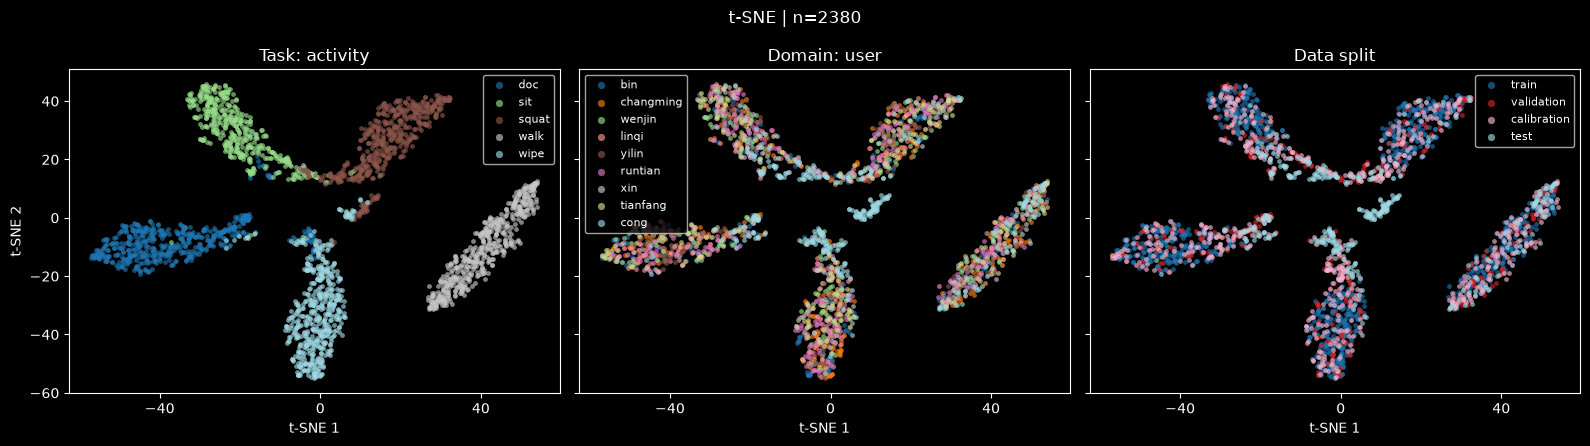

Saved: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261001T192314897806Z/conformal-20261003T011855070701Z/embedding_tsne.png
Computing Metric MDS for 2380 samples...


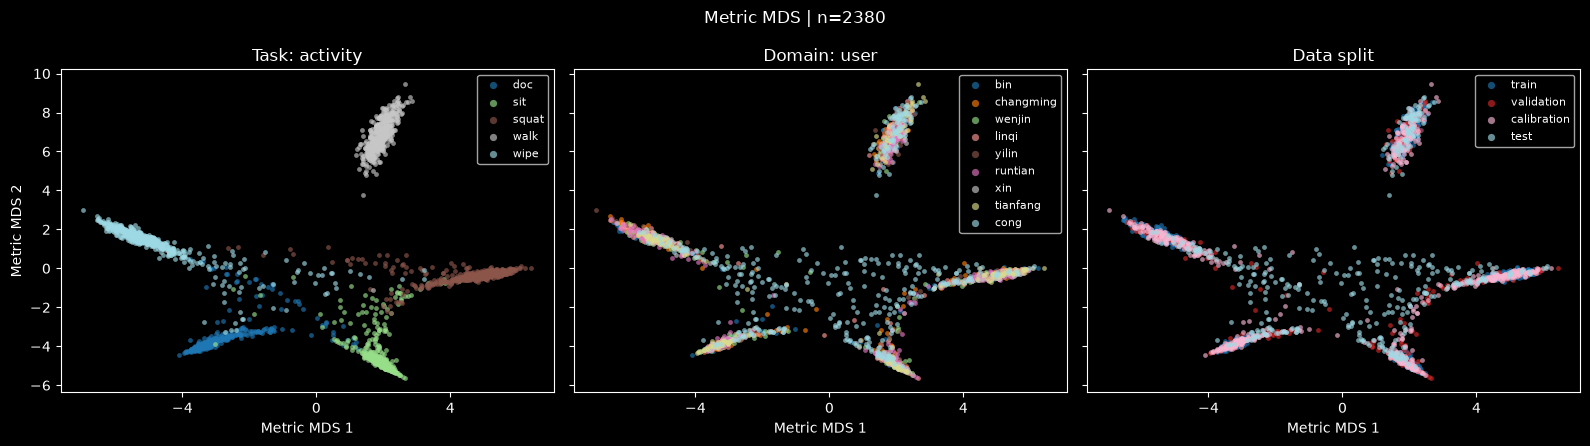

Saved: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261001T192314897806Z/conformal-20261003T011855070701Z/embedding_mds.png


In [21]:
if run_embedding_projections:
    from pathlib import Path
    import json
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE, Isomap, SpectralEmbedding, MDS
    from matplotlib.ticker import MaxNLocator

    viz_dir = Path(cp_dir)  # Or Path("runs/<run>/conformal-<timestamp>")
    viz_seed = 42
    viz_max_per_split = 1000  # Random subset per split; None keeps every segment.

    viz_manifest = json.loads((viz_dir.parent / "experiment.json").read_text())
    viz_domain_key = viz_manifest["data"]["domain_key"]
    viz_rng = np.random.default_rng(viz_seed)
    viz_embeddings, viz_labels, viz_domains, viz_splits = [], [], [], []
    viz_recordings, viz_segments = [], []
    for split in ("train", "validation", "calibration", "test"):
        with np.load(viz_dir / f"{split}_embeddings.npz") as arrays:
            selected = np.arange(len(arrays["labels"]))
            if viz_max_per_split is not None and len(selected) > viz_max_per_split:
                selected = np.sort(viz_rng.choice(selected, viz_max_per_split, replace=False))
            # Saved split pairs have the same row order as the embedding exports.
            pairs = np.asarray(viz_manifest["splits"][split])[selected]
            viz_embeddings.append(arrays["embeddings"][selected])
            viz_labels.extend(viz_manifest["class_names"][label] for label in arrays["labels"][selected])
            viz_domains.extend(viz_manifest["recordings"][i]["metadata"][viz_domain_key]
                                for i, j in pairs)
            viz_splits.extend([split] * len(selected))
            viz_recordings.extend(arrays["recording"][selected])
            viz_segments.extend(arrays["segment_index"][selected])

    viz_embeddings = np.concatenate(viz_embeddings)
    viz_labels, viz_domains, viz_splits = map(np.asarray, (viz_labels, viz_domains, viz_splits))

    map_neighbors = min(30, len(viz_embeddings) - 1)

    embedding_maps = {
        "tsne": TSNE(n_components=2, perplexity=min(30.0, len(viz_embeddings) - 1), init="pca",
                     learning_rate="auto", random_state=viz_seed),
        # "isomap": Isomap(n_components=2, n_neighbors=map_neighbors),
        # "spectral": SpectralEmbedding(n_components=2, n_neighbors=map_neighbors,
        #                               affinity="nearest_neighbors", random_state=viz_seed),
        "mds": MDS(n_components=2, n_init=4, max_iter=300,
                   init="random", eps=1e-6, random_state=viz_seed),
    }
    map_titles = {"tsne": "t-SNE", "isomap": "Isomap", "spectral": "Spectral Embedding", "mds": "Metric MDS"}
    for name, mapper in embedding_maps.items():
        print(f"Computing {map_titles[name]} for {len(viz_embeddings)} samples...", flush=True)
        coordinates = mapper.fit_transform(viz_embeddings)
        if name == "mds" and mapper.n_iter_ >= mapper.max_iter:
            print("MDS reached max_iter; increase max_iter in embedding_maps to check convergence.")
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
        for ax, values, title in zip(axes, (viz_labels, viz_domains, viz_splits),
                                    (f"Task: {viz_manifest['task']}", f"Domain: {viz_domain_key}", "Data split")):
            categories = list(dict.fromkeys(values))
            colors = plt.get_cmap("tab20", len(categories))
            for i, category in enumerate(categories):
                selected = values == category
                ax.scatter(*coordinates[selected].T, s=12, alpha=0.65,
                           color=colors(i), label=category, linewidths=0)
            ax.set(title=title, xlabel=f"{map_titles[name]} 1")
            ax.xaxis.set_major_locator(MaxNLocator(4))
            ax.legend(fontsize=8, markerscale=1.5)
        axes[0].set_ylabel(f"{map_titles[name]} 2")
        fig.suptitle(f"{map_titles[name]} | n={len(viz_embeddings)}")
        fig.tight_layout()
        fig.savefig(viz_dir / f"embedding_{name}.png", dpi=180)
        np.savez_compressed(viz_dir / f"embedding_{name}.npz", coordinates=coordinates,
                            labels=viz_labels, domains=viz_domains, splits=viz_splits,
                            recording=np.asarray(viz_recordings), segment_index=np.asarray(viz_segments),
                            parameters=json.dumps(mapper.get_params()), seed=viz_seed,
                            max_per_split=-1 if viz_max_per_split is None else viz_max_per_split)
        plt.show()
        print("Saved:", viz_dir / f"embedding_{name}.png")

else:
    print("Projection skipped. Set run_embedding_projections=True to run this cell.")